In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

In [2]:
from dask.distributed import Client
client = Client(n_workers=4, threads_per_worker=3, memory_limit=15e9)
client

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35895 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:35895/status,
Dashboard: http://127.0.0.1:35895/status,Workers: 4
Total threads: 12,Total memory: 55.88 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37925,Workers: 0
Dashboard: http://127.0.0.1:35895/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37717,Total threads: 3
Dashboard: http://127.0.0.1:41273/status,Memory: 13.97 GiB
Nanny: tcp://127.0.0.1:42569,


In [3]:
!echo dask dashboard :D
!echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

dask dashboard :D
https://jupyterhub.dkrz.de/user/b383184/levante-spawner-preset/proxy/8787/status


In [4]:
# stores1 = sorted(Path("/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678").glob("Parcels_run_*_*.zarr"))
ds_traj = xr.open_zarr("/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678/Parcels_run_45678_1995-04-17 00:00:00.zarr").compute()
ds_traj

<xarray.Dataset> Size: 296MB
Dimensions:     (trajectory: 10000, obs: 740)
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 733 734 735 736 737 738 739
  * trajectory  (trajectory) int64 80kB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float64 59MB 0.2145 0.2238 ... 1.125 1.125
    lon         (trajectory, obs) float64 59MB -49.28 -49.3 ... -49.54 -49.54
    sal         (trajectory, obs) float32 30MB 0.3499 0.3545 ... 1.564e-12
    temp        (trajectory, obs) float32 30MB 27.44 27.49 ... 1.655e-12
    time        (trajectory, obs) datetime64[ns] 59MB 1995-04-17 ... 1995-10-...
    z           (trajectory, obs) float64 59MB 4.637 4.635 4.624 ... 14.6 14.6
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [35]:
np.random.seed(120)  # 
random_indices = np.random.choice(ds_traj.sizes["trajectory"], size=1000, replace=False)

# Subset the dataset
ds_traj_subset = ds_traj.isel(trajectory=random_indices)

ds_traj_subset

<xarray.Dataset> Size: 30MB
Dimensions:     (trajectory: 1000, obs: 740)
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 733 734 735 736 737 738 739
  * trajectory  (trajectory) int64 8kB 3223 3686 9378 7588 ... 8480 1044 1744
Data variables:
    lat         (trajectory, obs) float64 6MB 0.8927 0.9127 ... 2.205 2.205
    lon         (trajectory, obs) float64 6MB -49.73 -49.73 ... -50.46 -50.46
    sal         (trajectory, obs) float32 3MB 0.4577 0.4559 ... 7.194e-13
    temp        (trajectory, obs) float32 3MB 27.38 27.38 ... 1.207e-12
    time        (trajectory, obs) datetime64[ns] 6MB 1995-04-17 ... 1995-10-1...
    z           (trajectory, obs) float64 6MB 4.953 4.572 4.218 ... 14.6 14.6
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:498: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)


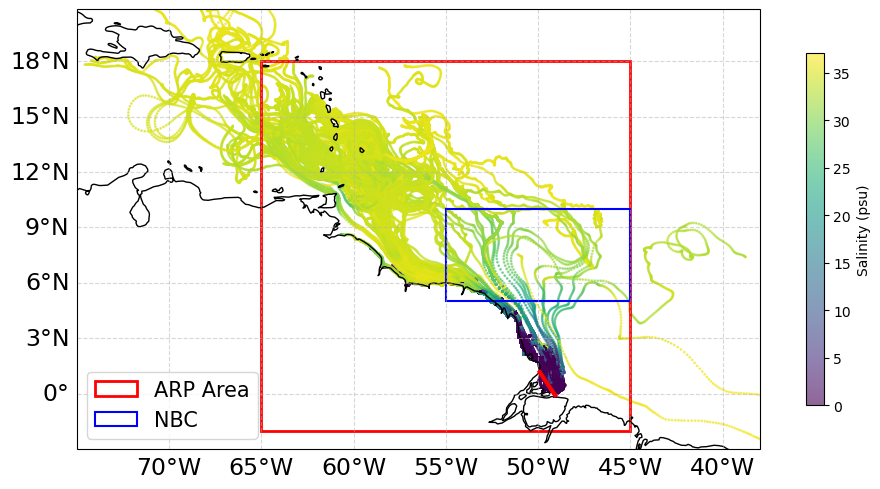

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5), subplot_kw={"projection": ccrs.PlateCarree()})
# fig.set_dpi(100)

# Plot each trajectory colored by salinity
for n in range(ds_traj_subset.sizes["trajectory"]):
    traj = ds_traj_subset.isel(trajectory=n).dropna("obs")
    sc = ax.scatter(
        traj.lon.values,
        traj.lat.values,
        c=traj.sal.values,
        s=1,
        cmap='viridis',
        vmin=ds_traj.sal.min(),  # consistent color scale across all trajectories
        vmax=ds_traj.sal.max(),
        transform=ccrs.PlateCarree(),
        alpha=0.6
    )

# Add colorbar
cb = fig.colorbar(sc, ax=ax, label='Salinity (psu)', shrink=0.8)

# Add coastlines and gridlines
ax.coastlines()
ax = plt.gca()
rect = mpatches.Rectangle(
    xy=(-65, -2),           # bottom-left corner (lon, lat)
    width=20,              # 65W to 49W = 16 degrees
    height=20,             # 0N to 15N = 15 degrees
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    label='ARP Area'
)
rect2 = mpatches.Rectangle(
    xy=(-55, 5),
    width=10,
    height=5,
    linewidth=1.5,
    edgecolor='blue',
    facecolor='none',
    label='NBC'
)
ax.add_patch(rect)

ax.add_patch(rect2)
ax.legend(fontsize=15)

ax.set_extent([
    -75,
    -38,
    -3,
    20,
])
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 17}  # Adjust size as needed
gl.ylabel_style = {'size': 17}

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# ax.set_title('Salinity')
plt.plot([lon0,lon1],[lat0,lat1],linewidth=3,color='red',label='Initial position')

plt.tight_layout()
# plt.savefig('Release_location_1.png',dpi=300, bbox_inches='tight')

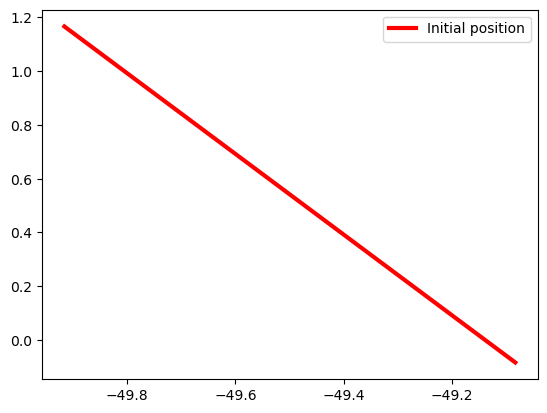

In [37]:
lon0 = -49.916
lon1 = -49.083
lat0 = 1.166
lat1 = -0.0833

plt.plot([lon0,lon1],[lat0,lat1],linewidth=3,color='red',label='Initial position')
plt.legend()

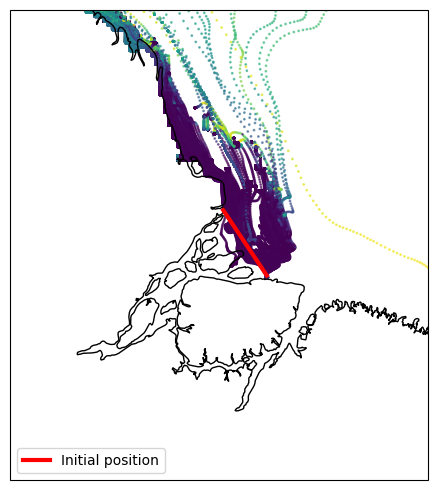

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5), subplot_kw={"projection": ccrs.PlateCarree()})
# fig.set_dpi(100)

# Plot each trajectory colored by salinity
for n in range(ds_traj_subset.sizes["trajectory"]):
    traj = ds_traj_subset.isel(trajectory=n).dropna("obs")
    sc = ax.scatter(
        traj.lon.values,
        traj.lat.values,
        c=traj.sal.values,
        s=1,
        cmap='viridis',
        vmin=ds_traj.sal.min(),  # consistent color scale across all trajectories
        vmax=ds_traj.sal.max(),
        transform=ccrs.PlateCarree(),
        alpha=0.6
    )

# Add colorbar
# cb = fig.colorbar(sc, ax=ax, label='Salinity (psu)', shrink=0.8)

# Add coastlines and gridlines
ax.coastlines()
ax = plt.gca()

ax.set_extent([
    -54,
    -46,
    -4,
    5,
])

plt.plot([lon0,lon1],[lat0,lat1],linewidth=3,color='red',label='Initial position')
plt.legend()

plt.tight_layout()
plt.savefig('Release_location_zoom.png',dpi=300, bbox_inches='tight')

### According to Liang and Dippner

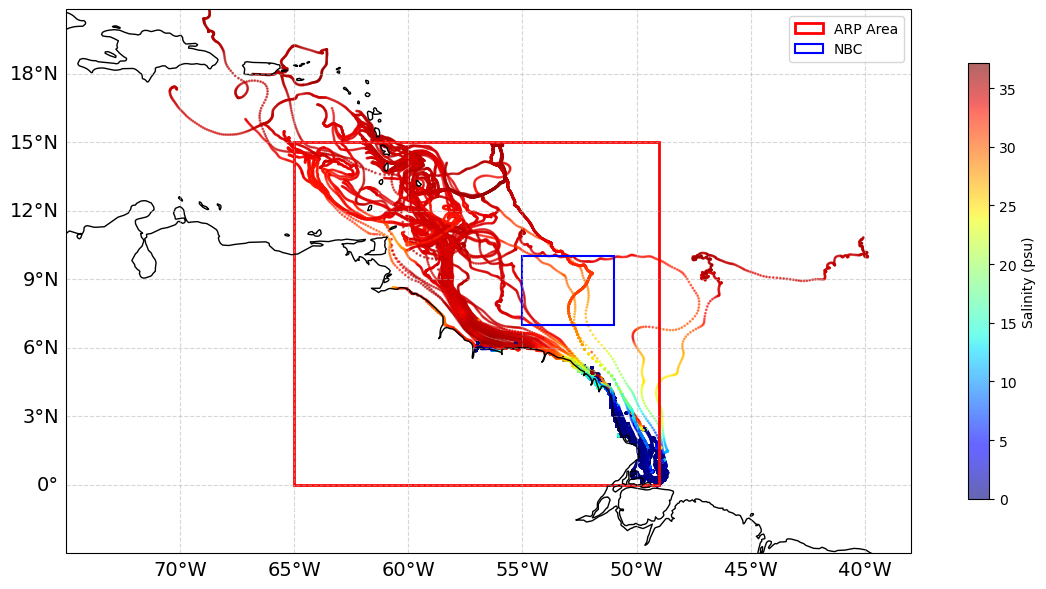

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})
# fig.set_dpi(100)

# Plot each trajectory colored by salinity
for n in range(ds_traj_subset.sizes["trajectory"]):
    traj = ds_traj_subset.isel(trajectory=n).dropna("obs")
    sc = ax.scatter(
        traj.lon.values,
        traj.lat.values,
        c=traj.sal.values,
        s=1,
        cmap='jet',
        vmin=ds_traj.sal.min(),  # consistent color scale across all trajectories
        vmax=ds_traj.sal.max(),
        transform=ccrs.PlateCarree(),
        alpha=0.6
    )

# Add colorbar
cb = fig.colorbar(sc, ax=ax, label='Salinity (psu)', shrink=0.8)

# Add coastlines and gridlines
ax.coastlines()
ax = plt.gca()
rect = mpatches.Rectangle(
    xy=(-65, 0),           # bottom-left corner (lon, lat)
    width=16,              # 65W to 49W = 16 degrees
    height=15,             # 0N to 15N = 15 degrees
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    label='ARP Area'
)
rect2 = mpatches.Rectangle(
    xy=(-55, 7),
    width=4,
    height=3,
    linewidth=1.5,
    edgecolor='blue',
    facecolor='none',
    label='NBC'
)
ax.add_patch(rect)

ax.add_patch(rect2)
ax.legend()

ax.set_extent([
    -75,
    -38,
    -3,
    20,
])
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 14}  # Adjust size as needed
gl.ylabel_style = {'size': 14}

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# ax.set_title('Salinity')

plt.tight_layout()
plt.show()